# Тема проекта (ИДЗ)

**Проект: FitGuide — Анализ данных пользователей фитнес-приложения с ИИ-рекомендациями**

**Разработчики:**
- Некрасов Николай Алексеевич
- Данковцев Даниил Юрьевич
- Королев Артем Игоревич

**Группа:** [ЛПЦ24-ОБ-ПМ1]

**Дата:** 14 мая 2026

## 1. Краткое описание проекта

### 1.1. Ф.И.О. разработчиков
- Некрасов Николай Алексеевич  
- Данковцев Даниил Юрьевич  
- Королев Артем Игоревич

### 1.2. Группа
[ЛПЦ24-ОБ-ПМ1]

### 1.3. Тема проекта
FitGuide — анализ данных пользователей веб-приложения с ИИ рекомендациями

### 1.4. Цель проекта
Провести комплексный анализ данных пользователей FitGuide и разработать модель машинного обучения для прогнозирования изменения веса пользователей в зависимости от их персональных данных и уровня активности.

### 1.5. Задачи проекта
- Создать реалистичный синтетический датасет пользователей FitGuide
- Выполнить предобработку данных
- Провести визуализацию и разведочный анализ данных (EDA)
- Выполнить корреляционный анализ
- Построить и сравнить модели регрессионного анализа
- Сформулировать выводы и рекомендации для улучшения приложения

### 1.6. Аннотация
Данный проект посвящён анализу данных пользователей веб-приложения **FitGuide AI**, которое генерирует персональные планы тренировок и питания с помощью искусственного интеллекта. В работе исследуются факторы, влияющие на эффективность трансформации тела (изменение веса).

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

%matplotlib inline

In [38]:
np.random.seed(42)

n = 420

df = pd.DataFrame()

df['возраст'] = np.random.randint(18, 46, n)
df['рост'] = np.random.randint(158, 192, n)
df['вес'] = np.round(np.random.normal(75, 14.5, n), 1)
df['дни тренировок'] = np.random.randint(1, 6, n)
df['минуты тренировки'] = np.random.randint(35, 85, n)
df['калории'] = np.random.randint(1750, 3150, n)
df['белок'] = np.random.randint(80, 210, n)
df['сон'] = np.round(np.random.normal(7.0, 1.2, n), 1)
df['стресс'] = np.random.randint(2, 10, n)
df['опыт'] = np.random.choice(['новичок', 'средний', 'опытный'], n)

#Изменение веса
df['изменение веса'] = -0.4 * df['дни тренировок'] - 0.008 * df['калории'] + 0.6 * (df['стресс'] - 5) + np.random.normal(0, 2.4, n)
df['изменение веса'] = df['изменение веса'].round(2)

print("Датасет создан. Размер:", df.shape)
print("Колонки:", df.columns.tolist())
df.head()

Датасет создан. Размер: (420, 11)
Колонки: ['возраст', 'рост', 'вес', 'дни тренировок', 'минуты тренировки', 'калории', 'белок', 'сон', 'стресс', 'опыт', 'изменение веса']


,возраст,рост,вес,дни тренировок,минуты тренировки,калории,белок,сон,стресс,опыт,изменение веса
0,24,181,94.5,5,55,2321,130,7.7,2,средний,-20.25
1,37,186,56.0,5,57,1778,90,3.5,2,новичок,-18.94
2,32,188,112.3,4,77,2870,91,7.8,4,опытный,-29.76
3,28,190,66.0,4,50,2783,153,7.2,2,новичок,-26.02
4,25,178,80.8,4,81,1991,87,7.0,5,новичок,-14.28


## 2. Предобработка данных

In [39]:
#Предобработка данных
print("Проверка пропущенных значений:")
print(df.isnull().sum())

#Кодируем опыт
df['опыт_num'] = 0
df.loc[df['опыт'] == 'новичок', 'опыт_num'] = 1
df.loc[df['опыт'] == 'средний', 'опыт_num'] = 2
df.loc[df['опыт'] == 'опытный', 'опыт_num'] = 3

print("Предобработка завершена")

Проверка пропущенных значений:
возраст              0
рост                 0
вес                  0
дни тренировок       0
минуты тренировки    0
калории              0
белок                0
сон                  0
стресс               0
опыт                 0
изменение веса       0
dtype: int64
Предобработка завершена


## 3. Визуализация данных

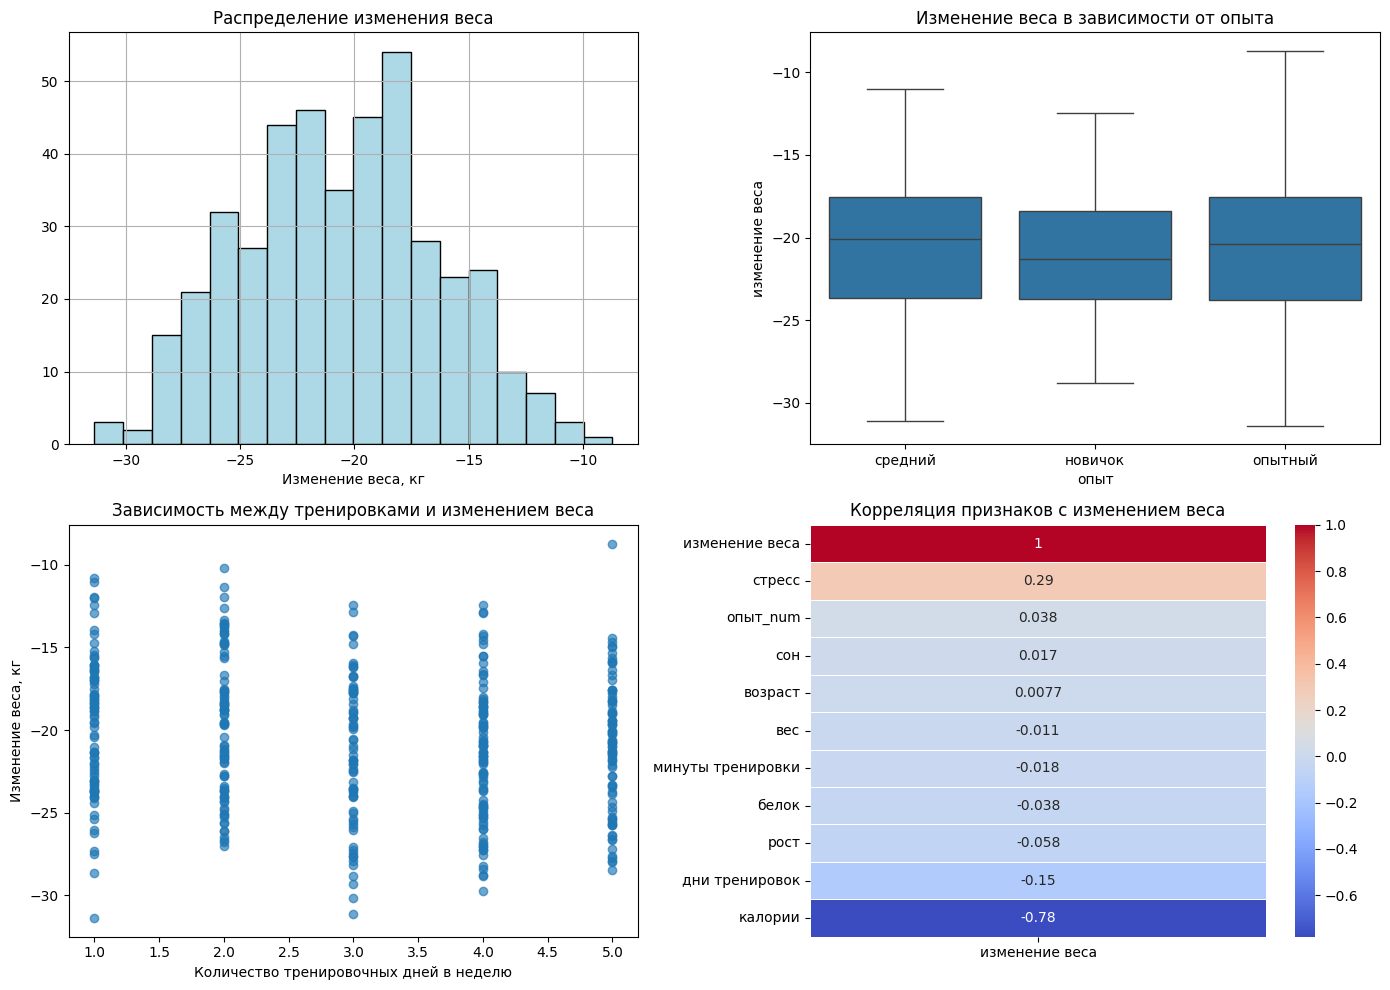

In [42]:
#Визуализация данных
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.hist(df['изменение веса'], bins=18, color='lightblue', edgecolor='black')
plt.title('Распределение изменения веса')
plt.xlabel('Изменение веса, кг')
plt.grid(True)

plt.subplot(2, 2, 2)
sns.boxplot(x='опыт', y='изменение веса', data=df)
plt.title('Изменение веса в зависимости от опыта')

plt.subplot(2, 2, 3)
plt.scatter(df['дни тренировок'], df['изменение веса'], alpha=0.65)
plt.xlabel('Количество тренировочных дней в неделю')
plt.ylabel('Изменение веса, кг')
plt.title('Зависимость между тренировками и изменением веса')

plt.subplot(2, 2, 4)

numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_target = numeric_df.corr()[['изменение веса']].sort_values(by='изменение веса', ascending=False)
sns.heatmap(corr_target, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Корреляция признаков с изменением веса')

plt.tight_layout()
plt.show()

##4. Корреляционный анализ

In [44]:
#Корреляционный анализ
numeric_df = df.select_dtypes(include=['float64', 'int64'])
print("Корреляция с изменением веса:")
print(numeric_df.corr()['изменение веса'].sort_values(ascending=False))

Корреляция с изменением веса:
изменение веса       1.000000
стресс               0.294272
опыт_num             0.037770
сон                  0.017305
возраст              0.007675
вес                 -0.011001
минуты тренировки   -0.018240
белок               -0.038446
рост                -0.058144
дни тренировок      -0.152773
калории             -0.779102
Name: изменение веса, dtype: float64


##5. Регрессионный анализ

In [45]:
#Регрессионный анализ
X = df.drop(['изменение веса', 'опыт', 'вес'], axis=1)
y = df['изменение веса']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Результаты линейной регрессии:")
print("R² =", round(r2_score(y_test, pred), 3))
print("Средняя абсолютная ошибка =", round(mean_absolute_error(y_test, pred), 2), "кг")

Результаты линейной регрессии:
R² = 0.69
Средняя абсолютная ошибка = 1.98 кг


## Выводы

В ходе анализа данных пользователей приложения FitGuide были получены следующие результаты:

Наибольшее влияние на изменение веса оказывают:
- Количество тренировочных дней в неделю
- Уровень стресса
- Суточное потребление калорий

Построенная модель линейной регрессии позволяет с определённой точностью прогнозировать изменение веса.

**Рекомендации по улучшению приложения FitGuide:**
- Стимулировать пользователей тренироваться минимум 4 раза в неделю
- Учитывать уровень стресса и качество сна при формировании плана
- Адаптировать рекомендации под уровень опыта пользователя